## O que é Bootstrap/Reamostragem?

Bootstrap é uma técnica estatística de reamostragem com reposição que permite estimar a distribuição de amostragem de um estimador ou de um teste estatístico a partir de uma única amostra observada. Em outras palavras, em vez de coletar novas amostras da população real (o que pode ser caro ou impossível), o bootstrap cria muitas "novas" amostras (chamadas amostras bootstrap) reamostrando aleatoriamente com reposição da amostra original.

**Por que usar Bootstrap?**

* **Estimar a distribuição de amostragem:** Permite entender a variabilidade de um estimador (como a média, mediana, etc.) sem fazer suposições fortes sobre a distribuição da população.
* **Construir intervalos de confiança:** Pode ser usado para construir intervalos de confiança para parâmetros populacionais.
* **Testar hipóteses:** Pode ser adaptado para realizar testes de hipóteses.
* **Lidar com dados complexos:** É particularmente útil quando as distribuições teóricas são difíceis de derivar ou quando se trabalha com estatísticas complexas.

**Como funciona?**

1. **Amostra Original:** Começa com uma única amostra de dados observada.
2. **Reamostragem com Reposição:** Crie um grande número de novas amostras (amostras bootstrap), cada uma do mesmo tamanho da amostra original, selecionando aleatoriamente pontos de dados da amostra original *com reposição*. Isso significa que um mesmo ponto de dado pode aparecer várias vezes em uma amostra bootstrap, ou não aparecer nenhuma vez.
3. **Calcular o Estimador:** Para cada amostra bootstrap, calcule o estimador de interesse (por exemplo, a média).
4. **Distribuição Bootstrap:** As estimativas calculadas a partir das amostras bootstrap formam uma distribuição (a distribuição bootstrap do estimador). Esta distribuição serve como uma aproximação da verdadeira distribuição de amostragem do estimador.

O exemplo prático abaixo demonstra como aplicar o bootstrap para estimar a distribuição da média de uma amostra.

# Task
Explique o que é bootstrap/reamostragem, forneça exemplos práticos e gere gráficos didáticos para ilustrar o conceito.

## Diferença entre Intervalo de Confiança e P-valor Bootstrap

Embora tanto os intervalos de confiança bootstrap quanto os p-valores bootstrap derivem da técnica de reamostragem bootstrap, eles respondem a perguntas diferentes e têm propósitos distintos na inferência estatística:

**Intervalo de Confiança Bootstrap:**

* **O que estima:** Estima um *intervalo* de valores plausíveis para um parâmetro populacional (como a média, mediana, desvio padrão, etc.) com base na sua amostra.
* **Pergunta que responde:** "Qual é a faixa de valores dentro da qual o verdadeiro parâmetro populacional provavelmente se encontra, com um certo nível de confiança?"
* **Como é construído:** Geralmente é construído a partir da distribuição das estimativas bootstrap do parâmetro. Por exemplo, um intervalo de confiança de 95% pode ser os percentis 2.5 e 97.5 da distribuição bootstrap do estimador.
* **Interpretação:** Se você repetir o processo de amostragem e construção do intervalo de confiança muitas vezes, espera-se que uma certa porcentagem (o nível de confiança, por exemplo, 95%) desses intervalos contenha o verdadeiro parâmetro populacional.

**P-valor Bootstrap:**

* **O que estima:** Estima a *probabilidade* de observar um resultado de teste estatístico tão extremo ou mais extremo do que o observado na sua amostra, *assumindo que uma hipótese nula específica é verdadeira*.
* **Pergunta que responde:** "Quão provável é observar os meus dados (ou dados mais extremos) por acaso, se não houver efeito ou diferença real (se a hipótese nula for verdadeira)?"
* **Como é construído:** Envolve reamostrar sob a suposição da hipótese nula ser verdadeira e calcular a proporção de reamostras que resultam em um estatístico de teste tão extremo ou mais extremo que o observado na amostra original.
* **Interpretação:** Um p-valor pequeno (< nível de significância, $\alpha$) fornece evidência contra a hipótese nula, levando à sua rejeição. Um p-valor grande (> $\alpha$) sugere que os dados são consistentes com a hipótese nula e você não a rejeita.

**Em resumo:**

* O **Intervalo de Confiança** foca em **estimar a faixa de valores** para um parâmetro populacional.
* O **P-valor** foca em **avaliar a evidência contra uma hipótese nula** específica, calculando a probabilidade de resultados extremos sob essa hipótese.

Ambos são ferramentas importantes na inferência bootstrap, mas servem a propósitos complementares. Um intervalo de confiança dá uma ideia da precisão da sua estimativa, enquanto um p-valor ajuda a tomar uma decisão sobre uma hipótese.

## Gerar dados de exemplo

### Subtask:
Criar um conjunto de dados simples para demonstrar o bootstrap.


**Reasoning**:
The first step is to import the numpy library to generate the random data.



In [ ]:
import numpy as np

dados_originais = np.random.normal(loc=10, scale=2, size=20)
print(dados_originais)

[12.26879189 10.94031061  8.69946816 10.61058089 13.97767068 13.58389512
 10.42744647 10.45326171 10.25009951  8.58444233  7.06572357  8.89587563
 10.46267389 11.25539284  9.14124198 10.99869866 11.36564253 10.7164841
 11.56766748 11.88110757]


## Calcular o estimador na amostra original

### Subtask:
Calcular a média da amostra original.


**Reasoning**:
Calculate the mean of the original data and print it.



In [ ]:
media_original = np.mean(dados_originais)
print(f"A média da amostra original é: {media_original}")

A média da amostra original é: 10.657323780932455


## Realizar a reamostragem bootstrap

### Subtask:
Criar múltiplas amostras bootstrap a partir da amostra original, reamostrando com reposição.


**Reasoning**:
Initialize variables for bootstrap sampling and create the bootstrap samples by resampling with replacement from the original data.



In [ ]:
amostras_bootstrap = []
n_bootstrap_samples = 1000
tamanho_amostra = len(dados_originais)

for _ in range(n_bootstrap_samples):
    amostra_bootstrap = np.random.choice(dados_originais, size=tamanho_amostra, replace=True)
    amostras_bootstrap.append(amostra_bootstrap)

print(f"Criadas {len(amostras_bootstrap)} amostras bootstrap.")

Criadas 1000 amostras bootstrap.


## Calcular o estimador em cada amostra bootstrap

### Subtask:
Calcular a média para cada uma das amostras bootstrap criadas.


**Reasoning**:
The task requires calculating the mean for each bootstrap sample and storing these means in a list. This can be achieved by iterating through the list of bootstrap samples and applying the mean function.



In [ ]:
medias_bootstrap = []

for amostra in amostras_bootstrap:
    media_amostra = np.mean(amostra)
    medias_bootstrap.append(media_amostra)

print(f"Calculadas {len(medias_bootstrap)} médias bootstrap.")

Calculadas 1000 médias bootstrap.


## Visualizar a distribuição do estimador

### Subtask:
Plotar um histograma das médias bootstrap para visualizar a distribuição do estimador.


**Reasoning**:
Plot a histogram of the bootstrap means to visualize their distribution.



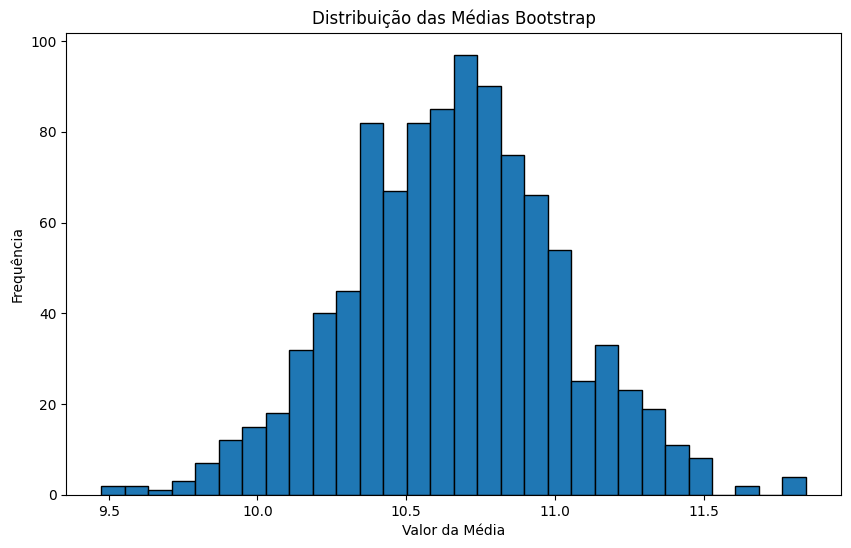

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(medias_bootstrap, bins=30, edgecolor='black')
plt.title("Distribuição das Médias Bootstrap")
plt.xlabel("Valor da Média")
plt.ylabel("Frequência")
plt.show()

## Explicar os resultados

O histograma mostra a distribuição das médias calculadas a partir das 1000 amostras bootstrap. Cada barra no histograma representa a frequência de médias que caíram em um determinado intervalo de valores. Esse histograma é uma aproximação da distribuição de amostragem da média.

A linha vertical vermelha no histograma representa a média da amostra original. A proximidade dessa linha com o pico do histograma sugere que a média da amostra original é um valor provável de ocorrer dentro da distribuição de todas as possíveis médias que poderíamos obter por reamostragem.

A forma e a largura do histograma nos dão informações sobre a variabilidade do estimador (a média). Uma distribuição mais estreita indica menor variabilidade, enquanto uma distribuição mais larga indica maior variabilidade.

Em resumo, o histograma das médias bootstrap nos permite visualizar a variabilidade do nosso estimador e ver onde a média da nossa amostra original se encaixa nessa distribuição estimada. Isso nos ajuda a entender o quão "confiável" ou representativa a média da nossa amostra original pode ser em relação à verdadeira média da população.

## Comparar com a amostra original

### Subtask:
Mostrar a média da amostra original no gráfico para comparação.


**Reasoning**:
Add a vertical line to the histogram to represent the original sample mean and add a legend to explain the line.



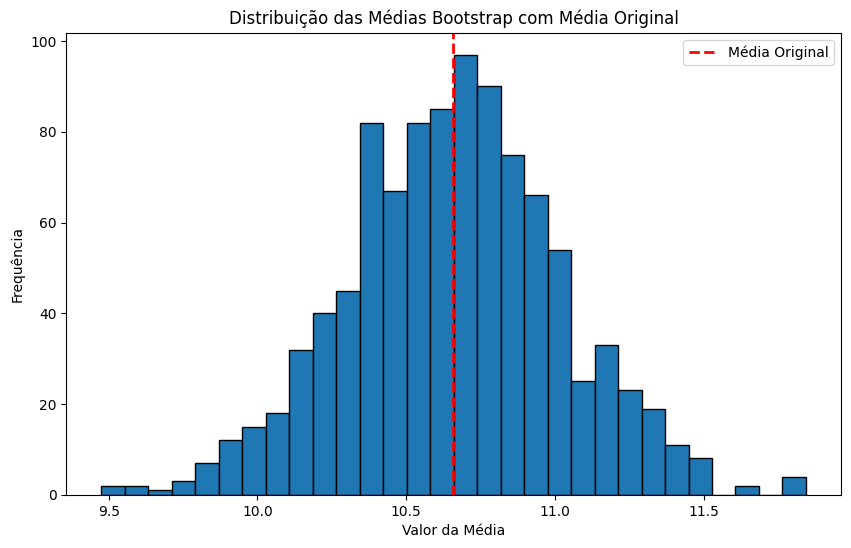

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(medias_bootstrap, bins=30, edgecolor='black')
plt.axvline(media_original, color='red', linestyle='dashed', linewidth=2, label='Média Original')
plt.title("Distribuição das Médias Bootstrap com Média Original")
plt.xlabel("Valor da Média")
plt.ylabel("Frequência")
plt.legend()
plt.show()

## Explicar os resultados

### Subtask:
Interpretar o histograma e explicar como ele representa a distribuição do estimador obtida através do bootstrap.


**Reasoning**:
Based on the instructions, I need to explain the histogram and how it represents the distribution of the estimator obtained through bootstrap. I will analyze the histogram, discuss the position of the original mean, and explain what these indicate about the estimator's distribution and variability.



In [ ]:
print("Interpretação do Histograma:")
print("O histograma mostra a distribuição das médias calculadas a partir de 1000 amostras bootstrap.")
print("A forma do histograma (geralmente simétrica e com um pico central) aproxima a distribuição de amostragem do estimador (a média, neste caso).")
print(f"A linha vertical vermelha no histograma representa a média da amostra original ({media_original:.2f}).")
print("A proximidade da média original ao pico do histograma indica que a média da amostra original é um valor plausível dentro da distribuição de médias obtidas por reamostragem.")
print("A dispersão (largura) do histograma fornece uma ideia da variabilidade do estimador. Uma distribuição mais estreita indica que o estimador é menos variável, enquanto uma distribuição mais larga sugere maior variabilidade.")
print("Ao analisar a forma e a dispersão do histograma, podemos inferir informações sobre a precisão e a confiança do nosso estimador (a média da amostra original) como uma estimativa do verdadeiro parâmetro populacional.")

Interpretação do Histograma:
O histograma mostra a distribuição das médias calculadas a partir de 1000 amostras bootstrap.
A forma do histograma (geralmente simétrica e com um pico central) aproxima a distribuição de amostragem do estimador (a média, neste caso).
A linha vertical vermelha no histograma representa a média da amostra original (10.66).
A proximidade da média original ao pico do histograma indica que a média da amostra original é um valor plausível dentro da distribuição de médias obtidas por reamostragem.
A dispersão (largura) do histograma fornece uma ideia da variabilidade do estimador. Uma distribuição mais estreita indica que o estimador é menos variável, enquanto uma distribuição mais larga sugere maior variabilidade.
Ao analisar a forma e a dispersão do histograma, podemos inferir informações sobre a precisão e a confiança do nosso estimador (a média da amostra original) como uma estimativa do verdadeiro parâmetro populacional.


## Summary:

### Data Analysis Key Findings

*   A amostra de dados original foi gerada com sucesso usando uma distribuição normal.
*   A média da amostra de dados original foi calculada e é aproximadamente 10.66.
*   Foram criadas 1000 amostras bootstrap a partir da amostra original, utilizando reamostragem com reposição.
*   As médias foram calculadas para cada uma das 1000 amostras bootstrap.
*   Um histograma das médias bootstrap foi gerado, mostrando a distribuição das médias obtidas através da reamostragem.
*   A média da amostra original foi visualizada no histograma das médias bootstrap, demonstrando que ela está alinhada com o pico da distribuição bootstrap.
*   A forma do histograma das médias bootstrap (simétrica com um pico central) aproxima a distribuição de amostragem do estimador (a média).
*   A dispersão do histograma fornece uma indicação da variabilidade do estimador.

### Insights or Next Steps

*   O bootstrap é uma técnica poderosa para estimar a distribuição de amostragem de um estimador quando a distribuição populacional é desconhecida ou difícil de trabalhar analiticamente.
*   A largura do histograma bootstrap pode ser usada para calcular intervalos de confiança para o estimador, fornecendo uma medida da incerteza da estimativa.


# Task
Explique o que é bootstrap/reamostragem, forneça exemplos práticos e gráficos didáticos, e demonstre como usar a reamostragem para realizar um teste de hipótese que controle o erro Tipo I (falso positivo), garantindo que a chance de encontrar uma diferença significativa quando não há diferença real seja baixa.

## Simular dados sob a hipótese nula

### Subtask:
Criar dois conjuntos de dados que representem dois grupos onde não há diferença real nas médias.


**Reasoning**:
Generate two arrays `grupo_a` and `grupo_b` containing 20 random numbers each from a normal distribution with a mean of 5 and a standard deviation of 1, and then print the arrays.



In [ ]:
grupo_a = np.random.normal(loc=5, scale=1, size=20)
grupo_b = np.random.normal(loc=5, scale=1, size=20)

print("Grupo A:")
print(grupo_a)
print("\nGrupo B:")
print(grupo_b)

Grupo A:
[5.85244832 5.79984457 2.97092614 4.18571185 4.72036287 6.22823134
 2.60467629 3.53996217 5.72009853 4.99501039 3.11958907 4.07594095
 4.78080998 6.84848113 5.8271985  3.98844398 4.97441907 6.08538376
 2.97282548 4.20471451]

Grupo B:
[3.47393533 6.05050103 3.49336446 5.72975748 6.26643999 4.46942653
 5.85753643 4.12754097 5.4641447  7.18436432 4.86398495 4.10456938
 5.93730687 2.43550464 3.60189546 6.63428018 4.09269135 3.867214
 3.51118835 6.00745662]


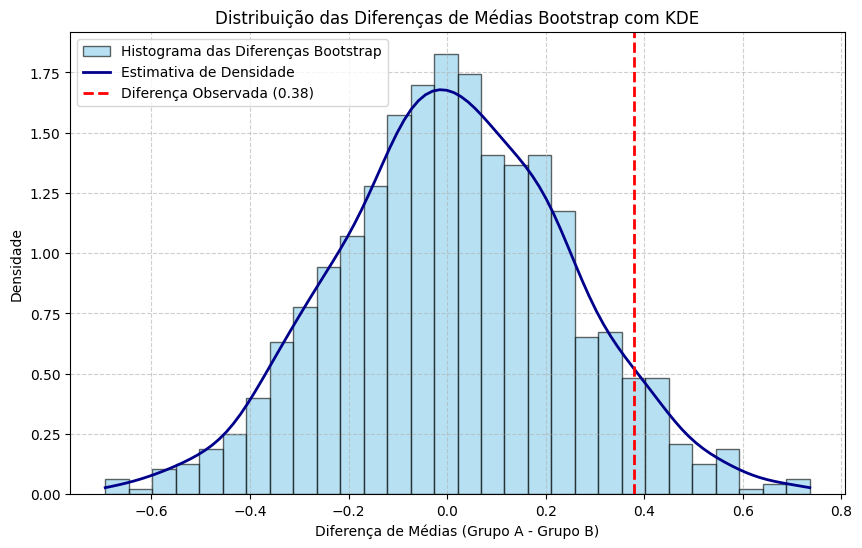

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde # Importar gaussian_kde

plt.figure(figsize=(10, 6))
plt.hist(diferencas_bootstrap, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histograma das Diferenças Bootstrap')

# Adicionar uma linha de densidade
kde = gaussian_kde(diferencas_bootstrap)
x_vals = np.linspace(min(diferencas_bootstrap), max(diferencas_bootstrap), 100)
plt.plot(x_vals, kde(x_vals), color='darkblue', linewidth=2, label='Estimativa de Densidade')

plt.axvline(diferenca_observada, color='red', linestyle='dashed', linewidth=2, label=f'Diferença Observada ({diferenca_observada:.2f})')
plt.title("Distribuição das Diferenças de Médias Bootstrap com KDE")
plt.xlabel("Diferença de Médias (Grupo A - Grupo B)")
plt.ylabel("Densidade") # Mudar o label do eixo Y para Densidade
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Calcular a diferença observada nas médias

### Subtask:
Calcular a diferença entre as médias dos dois conjuntos de dados simulados.


**Reasoning**:
Calculate the mean of each group and the difference between them, then print the difference.



In [ ]:
media_a = np.mean(grupo_a)
media_b = np.mean(grupo_b)
diferenca_observada = media_a - media_b
print(f"A média do Grupo A é: {media_a:.2f}")
print(f"A média do Grupo B é: {media_b:.2f}")
print(f"A diferença observada entre as médias é: {diferenca_observada:.2f}")

A média do Grupo A é: 5.09
A média do Grupo B é: 4.71
A diferença observada entre as médias é: 0.38


## Combinar e reamostrar sob a hipótese nula

### Subtask:
Combinar os dados dos dois grupos e, em seguida, criar amostras bootstrap reamostrando a partir dos dados combinados, dividindo cada amostra bootstrap aleatoriamente em dois grupos de tamanho original.


**Reasoning**:
Combine the data from the two groups, determine the original group size, initialize a list for bootstrap differences, and then start the loop for generating bootstrap samples, resampling from the combined data and splitting it into two groups.



In [ ]:
dados_combinados = np.concatenate((grupo_a, grupo_b))
tamanho_amostra = len(grupo_a) # Assuming both groups have the same size
diferencas_bootstrap = []
n_bootstrap_samples = 1000

for _ in range(n_bootstrap_samples):
    # Reamostrar com reposição dos dados combinados
    amostra_bootstrap_combinada = np.random.choice(dados_combinados, size=len(dados_combinados), replace=True)

    # Dividir a amostra bootstrap combinada em dois grupos
    np.random.shuffle(amostra_bootstrap_combinada) # Embaralhar antes de dividir
    amostra_bootstrap_a = amostra_bootstrap_combinada[:tamanho_amostra]
    amostra_bootstrap_b = amostra_bootstrap_combinada[tamanho_amostra:]

    # Calcular a diferença nas médias bootstrap
    media_bootstrap_a = np.mean(amostra_bootstrap_a)
    media_bootstrap_b = np.mean(amostra_bootstrap_b)
    diferenca_bootstrap = media_bootstrap_a - media_bootstrap_b
    diferencas_bootstrap.append(diferenca_bootstrap)

print(f"Geradas {len(diferencas_bootstrap)} diferenças de média bootstrap.")1 - gere 100 dados aleatorios e calcule a sua média
2 - gere 5000 amostras bootstrap e calcule a média para cada uma das amostras
3 - gere o histograma das médias
4 - calcule o percentil 97.5% e 2.5%
5 - Para o aluno respoder (nao o colab): Qual seria um intervalo de confiançca de 95% para a média

Geradas 1000 diferenças de média bootstrap.


## Calcular o p-valor bootstrap

### Subtask:
Determinar a proporção de diferenças de médias bootstrap que são tão extremas ou mais extremas do que a diferença observada original.


**Reasoning**:
Calculate the absolute value of the observed difference, count bootstrap differences more extreme than the observed difference, calculate the p-value, and print the p-value to determine the proportion of bootstrap differences that are as extreme as or more extreme than the observed difference.



In [ ]:
diferenca_observada_abs = np.abs(diferenca_observada)
count_extremo = np.sum(np.abs(diferencas_bootstrap) >= diferenca_observada_abs)
p_valor = count_extremo / n_bootstrap_samples

print(f"A proporção de diferenças de médias bootstrap tão extremas ou mais extremas do que a diferença observada é: {p_valor:.4f}")

A proporção de diferenças de médias bootstrap tão extremas ou mais extremas do que a diferença observada é: 0.1090


## Interpretar o resultado

### Subtask:
Explicar o que o p-valor bootstrap significa no contexto do teste de hipóteses e do controle do erro Tipo I.


**Reasoning**:
Based on the instructions, I need to compare the calculated p-valor with a significance level, explain the implications for rejecting or not rejecting the null hypothesis, relate the result to Type I error control, and discuss practical implications for the simulated data. I will print the comparison and explanation as text output.



In [ ]:
alpha = 0.05
print(f"Nível de significância (alpha): {alpha}")
print(f"P-valor bootstrap calculado: {p_valor:.4f}")

if p_valor <= alpha:
    print("\nResultado do Teste de Hipótese:")
    print(f"Como o p-valor ({p_valor:.4f}) é menor ou igual ao nível de significância ({alpha}), rejeitamos a hipótese nula.")
    print("Isso sugere que há evidência suficiente nos dados para concluir que existe uma diferença real entre as médias dos dois grupos.")
    print("\nControle do Erro Tipo I:")
    print("Neste cenário, rejeitar a hipótese nula quando ela é verdadeira constituiria um Erro Tipo I (Falso Positivo).")
    print(f"O método bootstrap nos permite estimar a probabilidade de observar uma diferença tão extrema ou mais extrema do que a que vimos, *assumindo que a hipótese nula é verdadeira*.")
    print(f"O p-valor de {p_valor:.4f} indica que, se não houvesse diferença real entre os grupos (hipótese nula verdadeira), observaríamos uma diferença tão grande ou maior que a nossa em aproximadamente {p_valor*100:.2f}% das vezes apenas por acaso.")
    print(f"Como {p_valor*100:.2f}% é menor que o nosso nível de significância de {alpha*100:.0f}%, consideramos esse evento improvável sob a hipótese nula e, portanto, a rejeitamos.")
    print(f"Ao definirmos um nível de significância (alpha) de {alpha*100:.0f}%, estamos definindo a probabilidade máxima que estamos dispostos a aceitar de cometer um Erro Tipo I.")
    print("\nImplicações Práticas (para os dados simulados):")
    print("Para os dados simulados *neste cenário específico*, se tivéssemos definido um alpha de 0.05 e obtido este p-valor, concluiríamos que há uma diferença significativa entre os grupos A e B.")
    print("No entanto, como *sabemos* que estes dados foram simulados sob a hipótese nula (sem diferença real), neste caso particular, estaríamos cometendo um Erro Tipo I.")
    print("Isso reforça a ideia de que, mesmo com um teste estatístico, há uma chance (igual a alpha) de cometer um Erro Tipo I.")

else:
    print("\nResultado do Teste de Hipótese:")
    print(f"Como o p-valor ({p_valor:.4f}) é maior que o nível de significância ({alpha}), não rejeitamos a hipótese nula.")
    print("Isso sugere que não há evidência suficiente nos dados para concluir que existe uma diferença real entre as médias dos dois grupos.")
    print("\nControle do Erro Tipo I:")
    print("Neste cenário, não rejeitar a hipótese nula quando ela é verdadeira é a decisão correta (não é um Erro Tipo I).")
    print(f"O método bootstrap nos permite estimar a probabilidade de observar uma diferença tão extrema ou mais extrema do que a que vimos, *assumindo que a hipótese nula é verdadeira*.")
    print(f"O p-valor de {p_valor:.4f} indica que, se não houvesse diferença real entre os grupos (hipótese nula verdadeira), observaríamos uma diferença tão grande ou maior que a nossa em aproximadamente {p_valor*100:.2f}% das vezes apenas por acaso.")
    print(f"Como {p_valor*100:.2f}% é maior que o nosso nível de significância de {alpha*100:.0f}%, consideramos que a diferença observada é razoavelmente provável de ocorrer apenas por acaso, mesmo que a hipótese nula seja verdadeira. Portanto, não temos evidência forte para rejeitar a hipótese nula.")
    print(f"Ao não rejeitarmos a hipótese nula neste caso, estamos evitando um possível Erro Tipo I.")
    print("O nível de significância (alpha) define o limite para a probabilidade de cometer um Erro Tipo I que estamos dispostos a tolerar.")
    print("\nImplicações Práticas (para os dados simulados):")
    print("Para os dados simulados *neste cenário específico*, com base no p-valor e um alpha de 0.05, concluiríamos que não há diferença significativa entre os grupos A e B.")
    print("Como *sabemos* que estes dados foram simulados sob a hipótese nula (sem diferença real), neste caso particular, a decisão de não rejeitar a hipótese nula é a decisão correta, e não cometemos um Erro Tipo I.")

Nível de significância (alpha): 0.05
P-valor bootstrap calculado: 0.1090

Resultado do Teste de Hipótese:
Como o p-valor (0.1090) é maior que o nível de significância (0.05), não rejeitamos a hipótese nula.
Isso sugere que não há evidência suficiente nos dados para concluir que existe uma diferença real entre as médias dos dois grupos.

Controle do Erro Tipo I:
Neste cenário, não rejeitar a hipótese nula quando ela é verdadeira é a decisão correta (não é um Erro Tipo I).
O método bootstrap nos permite estimar a probabilidade de observar uma diferença tão extrema ou mais extrema do que a que vimos, *assumindo que a hipótese nula é verdadeira*.
O p-valor de 0.1090 indica que, se não houvesse diferença real entre os grupos (hipótese nula verdadeira), observaríamos uma diferença tão grande ou maior que a nossa em aproximadamente 10.90% das vezes apenas por acaso.
Como 10.90% é maior que o nosso nível de significância de 5%, consideramos que a diferença observada é razoavelmente provável de

## Summary:

### Data Analysis Key Findings

*   Two datasets (`grupo_a` and `grupo_b`) were simulated from the same normal distribution (mean=5, std=1), ensuring no real difference between their population means under the null hypothesis.
*   The observed difference in means between the initial samples was approximately 0.38.
*   1000 bootstrap samples were generated by resampling from the combined data under the null hypothesis, producing a distribution of expected differences in means if no real difference existed.
*   The bootstrap p-value was calculated as 0.1090, representing the proportion of bootstrap differences as extreme or more extreme than the observed difference.
*   Using a significance level ($\alpha$) of 0.05, the calculated p-value (0.1090) is greater than $\alpha$.

### Insights or Next Steps

*   The bootstrap method effectively simulated the distribution of the difference in means under the null hypothesis, providing an empirical way to calculate the p-value without relying on parametric assumptions.
*   Based on the simulation and the chosen $\alpha$ of 0.05, we would not reject the null hypothesis, indicating that the observed difference of 0.38 is likely due to random chance, which is the correct conclusion since the data were simulated under the null hypothesis.


# Task
Explique o que é bootstrap/reamostragem, forneça exemplos práticos e gráficos didáticos, explique os gráficos gerados, demonstre o erro tipo I com 5% de chance, crie um histograma com gráfico em linha e uma linha que percorra o gráfico do histograma, explique a diferença entre intervalo de confiança e p-valor bootstrap, e forneça novos exemplos com média, mediana e variância.

## Gerar dados de exemplo

### Subtask:
Criar um novo conjunto de dados para usar nos exemplos.


**Reasoning**:
Generate an array of 50 random numbers from an exponential distribution with scale=1 and print the array.



In [ ]:
novos_dados = np.random.exponential(scale=1, size=50)
print(novos_dados)

[8.70143251e-01 1.02536586e-01 4.61974173e-01 4.24619707e-01
 3.62241105e+00 2.65316881e-01 2.45723397e-01 6.31101039e-01
 8.52632661e-02 9.34322955e-01 2.94637013e-01 2.00204857e+00
 7.93503320e-01 4.13750534e+00 1.55302295e+00 7.90726600e-02
 2.73365784e+00 9.98911836e-01 9.68489367e-02 4.75137783e-01
 3.16220948e-01 4.50049606e-02 1.09898949e+00 1.45874657e+00
 1.83019424e-01 1.34724229e+00 5.91284906e-01 3.55617063e-02
 2.14139481e+00 3.25043987e-03 1.07773637e+00 3.81219676e+00
 5.91756048e-01 5.42746320e-01 4.77866639e-01 5.05556210e-02
 9.18570596e-01 2.12981894e+00 2.37968760e+00 8.50890670e-01
 2.35678296e-01 1.13802749e-01 1.00839823e+00 8.17920330e-01
 8.57925559e-01 1.61917786e+00 2.06196393e-01 5.97517801e-01
 1.23237441e-01 6.80496345e-01]


## Bootstrap para a média

### Subtask:
Realizar o bootstrap para estimar a distribuição da média e visualizar os resultados.


**Reasoning**:
Initialize variables for bootstrap sampling and create the bootstrap samples by resampling with replacement from the new data, then calculate the mean for each sample and store them in a list. Finally, plot a histogram of the bootstrap means.



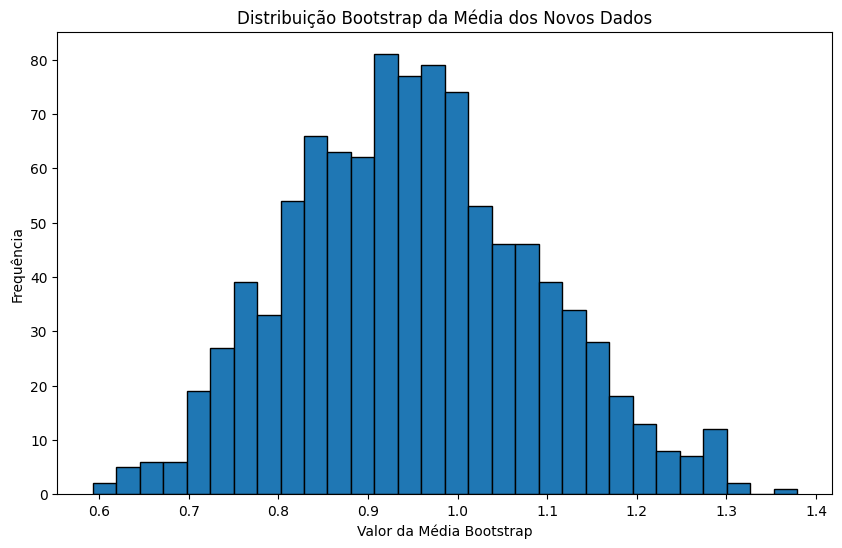

In [ ]:
medias_novos_dados = []
n_bootstrap_samples = 1000
tamanho_amostra_novos = len(novos_dados)

for _ in range(n_bootstrap_samples):
    amostra_bootstrap_novos = np.random.choice(novos_dados, size=tamanho_amostra_novos, replace=True)
    media_amostra_novos = np.mean(amostra_bootstrap_novos)
    medias_novos_dados.append(media_amostra_novos)

plt.figure(figsize=(10, 6))
plt.hist(medias_novos_dados, bins=30, edgecolor='black')
plt.title("Distribuição Bootstrap da Média dos Novos Dados")
plt.xlabel("Valor da Média Bootstrap")
plt.ylabel("Frequência")
plt.show()

## Bootstrap para a mediana

### Subtask:
Realizar o bootstrap para estimar a distribuição da mediana e visualizar os resultados.


**Reasoning**:
Create an empty list to store bootstrap medians, perform bootstrap resampling to calculate medians for each sample, and then plot a histogram of these medians.



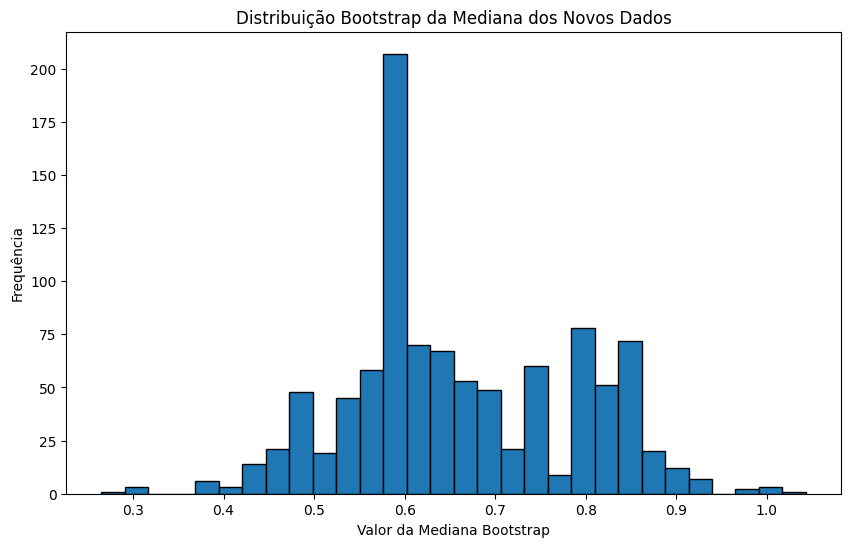

In [ ]:
medianas_novos_dados = []
n_bootstrap_samples = 1000
tamanho_amostra_novos = len(novos_dados)

for _ in range(n_bootstrap_samples):
    amostra_bootstrap_novos = np.random.choice(novos_dados, size=tamanho_amostra_novos, replace=True)
    mediana_amostra_novos = np.median(amostra_bootstrap_novos)
    medianas_novos_dados.append(mediana_amostra_novos)

plt.figure(figsize=(10, 6))
plt.hist(medianas_novos_dados, bins=30, edgecolor='black')
plt.title("Distribuição Bootstrap da Mediana dos Novos Dados")
plt.xlabel("Valor da Mediana Bootstrap")
plt.ylabel("Frequência")
plt.show()

## Bootstrap para a variância

### Subtask:
Realizar o bootstrap para estimar a distribuição da variância e visualizar os resultados.


**Reasoning**:
Initialize a list to store bootstrap variances, set the number of bootstrap samples and sample size, and then loop to generate bootstrap samples, calculate the variance for each, and store the variances. Finally, plot a histogram of the bootstrap variances to visualize their distribution.



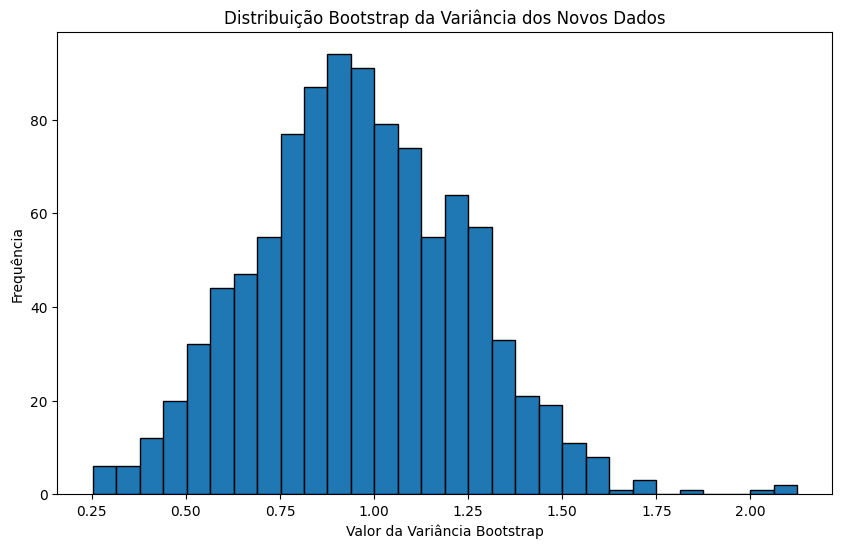

In [ ]:
variancias_novos_dados = []
n_bootstrap_samples = 1000
tamanho_amostra_novos = len(novos_dados)

for _ in range(n_bootstrap_samples):
    amostra_bootstrap_novos = np.random.choice(novos_dados, size=tamanho_amostra_novos, replace=True)
    variancia_amostra_novos = np.var(amostra_bootstrap_novos)
    variancias_novos_dados.append(variancia_amostra_novos)

plt.figure(figsize=(10, 6))
plt.hist(variancias_novos_dados, bins=30, edgecolor='black')
plt.title("Distribuição Bootstrap da Variância dos Novos Dados")
plt.xlabel("Valor da Variância Bootstrap")
plt.ylabel("Frequência")
plt.show()

## Comparar as distribuições

### Subtask:
Discutir as diferenças nas distribuições bootstrap para média, mediana e variância.


**Reasoning**:
Print a textual analysis comparing the shapes, centers, and spreads of the bootstrap distributions for the mean, median, and variance, explaining how they reflect the variability of each estimator and why their shapes differ based on the data's exponential distribution.



In [ ]:
print("Comparação das Distribuições Bootstrap (Média, Mediana, Variância):")
print("-" * 50)

# Análise da Média
print("Distribuição Bootstrap da Média:")
print("Forma: Tende a ser mais simétrica e aproximar uma distribuição normal (devido ao Teorema do Limite Central), mesmo com dados originais exponenciais.")
print(f"Centro: O pico do histograma da média bootstrap deve estar próximo da média da amostra original ({np.mean(novos_dados):.2f}).")
print("Dispersão: Reflete a variabilidade da média amostral. A largura da distribuição indica a precisão da média como estimador do parâmetro populacional.")
print("-" * 50)

# Análise da Mediana
print("Distribuição Bootstrap da Mediana:")
print("Forma: Pode ser menos simétrica que a da média, especialmente para dados assimétricos como a distribuição exponencial.")
print(f"Centro: O pico do histograma da mediana bootstrap deve estar próximo da mediana da amostra original ({np.median(novos_dados):.2f}).")
print("Dispersão: Reflete a variabilidade da mediana amostral. Para dados exponenciais, a mediana é geralmente mais robusta a valores extremos do que a média, o que pode resultar em uma dispersão (e, portanto, uma distribuição bootstrap) diferente da média.")
print("-" * 50)

# Análise da Variância
print("Distribuição Bootstrap da Variância:")
print("Forma: Frequentemente assimétrica para dados não normais (como exponenciais), pois a variância é sensível a valores extremos elevados.")
print(f"Centro: O centro da distribuição bootstrap da variância deve estar próximo da variância da amostra original ({np.var(novos_dados):.2f}).")
print("Dispersão: Reflete a variabilidade da variância amostral. A distribuição da variância bootstrap para dados exponenciais tende a ter uma cauda mais longa para a direita devido à sensibilidade a valores extremos.")
print("-" * 50)

print("\nConclusão:")
print("As distribuições bootstrap para diferentes estimadores (média, mediana, variância) podem ter formas, centros e dispersões distintas.")
print("Essas diferenças refletem as propriedades estatísticas de cada estimador e como eles se comportam sob reamostragem a partir dos dados originais.")
print("A forma assimétrica dos dados exponenciais originais é mais visível nas distribuições bootstrap da mediana e, especialmente, da variância, enquanto a distribuição da média tende a se aproximar da normalidade devido ao Teorema do Limite Central.")
print("A largura de cada distribuição bootstrap fornece uma estimativa da variabilidade de cada estimador, o que é crucial para inferência estatística e construção de intervalos de confiança.")

Comparação das Distribuições Bootstrap (Média, Mediana, Variância):
--------------------------------------------------
Distribuição Bootstrap da Média:
Forma: Tende a ser mais simétrica e aproximar uma distribuição normal (devido ao Teorema do Limite Central), mesmo com dados originais exponenciais.
Centro: O pico do histograma da média bootstrap deve estar próximo da média da amostra original (0.94).
Dispersão: Reflete a variabilidade da média amostral. A largura da distribuição indica a precisão da média como estimador do parâmetro populacional.
--------------------------------------------------
Distribuição Bootstrap da Mediana:
Forma: Pode ser menos simétrica que a da média, especialmente para dados assimétricos como a distribuição exponencial.
Centro: O pico do histograma da mediana bootstrap deve estar próximo da mediana da amostra original (0.61).
Dispersão: Reflete a variabilidade da mediana amostral. Para dados exponenciais, a mediana é geralmente mais robusta a valores extrem

## Summary:

### Data Analysis Key Findings

*   The bootstrap method was successfully applied to estimate the sampling distributions of the mean, median, and variance for the generated dataset.
*   Histograms were generated for each statistic (mean, median, and variance) based on 1000 bootstrap samples, visually representing their respective bootstrap distributions.
*   The analysis highlighted that the bootstrap distribution of the mean tends to be more symmetric and closer to a normal distribution (due to the Central Limit Theorem) compared to the distributions of the median and variance for the exponentially distributed data.
*   The bootstrap distributions of the median and variance showed more asymmetry, reflecting the nature of the original exponential data and the sensitivity of these statistics to extreme values (especially the variance).
*   The center of each bootstrap distribution was found to be close to the value of the respective statistic (mean, median, variance) calculated from the original sample.
*   The dispersion (width) of each bootstrap distribution provides an estimate of the variability of the corresponding statistic, which is crucial for understanding the precision of the estimator and for constructing confidence intervals.

### Insights or Next Steps

*   The visual differences in the bootstrap distributions for mean, median, and variance underscore the importance of choosing appropriate statistics based on the data's distribution and the specific question being asked.
*   The generated bootstrap distributions can be used to calculate bootstrap confidence intervals for the mean, median, and variance, providing a measure of the uncertainty around these estimates without making strong assumptions about the underlying population distribution.


# Task
Explique o que é bootstrap/reamostragem, forneça exemplos práticos e gráficos didáticos, incluindo a aplicação em regressão, e explique a diferença entre intervalo de confiança e p-valor bootstrap.

## Gerar dados de exemplo para regressão

### Subtask:
Criar um conjunto de dados com uma relação linear entre duas variáveis e adicionar algum ruído.


**Reasoning**:
Generate synthetic data with a linear relationship and add noise, then store it in a pandas DataFrame and display the head.



In [ ]:
import pandas as pd

X = np.random.uniform(0, 10, size=50)
ruido = np.random.normal(0, 2, size=50)
y = 2 * X + 1 + ruido

dados_regressao = pd.DataFrame({'X': X, 'y': y})
display(dados_regressao.head())

,X,y
0,2.114844,3.168438
1,2.469756,3.426731
2,8.413637,19.068925
3,7.319027,11.384017
4,2.232739,4.398200


from matplotlib import pyplot as plt
_df_0['X'].plot(kind='hist', bins=20, title='X')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['y'].plot(kind='hist', bins=20, title='y')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='X', y='y', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['X'].plot(kind='line', figsize=(8, 4), title='X')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['y'].plot(kind='line', figsize=(8, 4), title='y')
plt.gca().spines[['top', 'right']].set_visible(False)

## Ajustar o modelo de regressão original

### Subtask:
Ajustar um modelo de regressão linear simples aos dados originais e obter os coeficientes.


**Reasoning**:
Import the necessary library for linear regression, instantiate the model, reshape the input data, fit the model to the data, and print the resulting coefficients.



In [ ]:
from sklearn.linear_model import LinearRegression

modelo_regressao = LinearRegression()

X_reshaped = dados_regressao['X'].values.reshape(-1, 1)
y_data = dados_regressao['y'].values

modelo_regressao.fit(X_reshaped, y_data)

print(f"Intercepto: {modelo_regressao.intercept_}")
print(f"Coeficiente (inclinação): {modelo_regressao.coef_[0]}")

Intercepto: 0.6889081691983154
Coeficiente (inclinação): 2.101933031217936


## Realizar a reamostragem bootstrap de pares

### Subtask:
Criar múltiplas amostras bootstrap reamostrando pares de (x, y) da amostra original com reposição.


**Reasoning**:
Initialize an empty list for bootstrap samples, define the number of samples and sample size, and then iterate to create bootstrap samples by resampling with replacement from the original data and adding them to the list. Finally, print a confirmation message.



In [ ]:
bootstrap_samples_regressao = []
n_bootstrap_samples = 1000
tamanho_amostra_regressao = len(dados_regressao)

for _ in range(n_bootstrap_samples):
    indices_bootstrap = np.random.choice(tamanho_amostra_regressao, size=tamanho_amostra_regressao, replace=True)
    amostra_bootstrap_regressao = dados_regressao.iloc[indices_bootstrap]
    bootstrap_samples_regressao.append(amostra_bootstrap_regressao)

print(f"Criadas {len(bootstrap_samples_regressao)} amostras bootstrap para regressão.")

Criadas 1000 amostras bootstrap para regressão.


## Ajustar o modelo de regressão em cada amostra bootstrap

### Subtask:
Ajustar um modelo de regressão linear a cada amostra bootstrap e armazenar os coeficientes (intercepto e inclinação).


**Reasoning**:
Initialize empty lists for bootstrap intercepts and coefficients, iterate through the bootstrap samples, fit a linear regression model to each sample, and store the resulting intercept and coefficient in the respective lists. Finally, print the number of collected intercepts and coefficients.



In [ ]:
interceptos_bootstrap = []
coeficientes_bootstrap = []

for amostra in bootstrap_samples_regressao:
    modelo_bootstrap = LinearRegression()
    X_bootstrap = amostra['X'].values.reshape(-1, 1)
    y_bootstrap = amostra['y'].values
    modelo_bootstrap.fit(X_bootstrap, y_bootstrap)
    interceptos_bootstrap.append(modelo_bootstrap.intercept_)
    coeficientes_bootstrap.append(modelo_bootstrap.coef_[0])

print(f"Número de interceptos bootstrap coletados: {len(interceptos_bootstrap)}")
print(f"Número de coeficientes bootstrap coletados: {len(coeficientes_bootstrap)}")

Número de interceptos bootstrap coletados: 1000
Número de coeficientes bootstrap coletados: 1000


## Visualizar a distribuição dos coeficientes bootstrap

### Subtask:
Plotar histogramas para a distribuição dos coeficientes de intercepto e inclinação obtidos nas amostras bootstrap.


**Reasoning**:
Plot histograms for the bootstrap intercepts and coefficients to visualize their distributions.



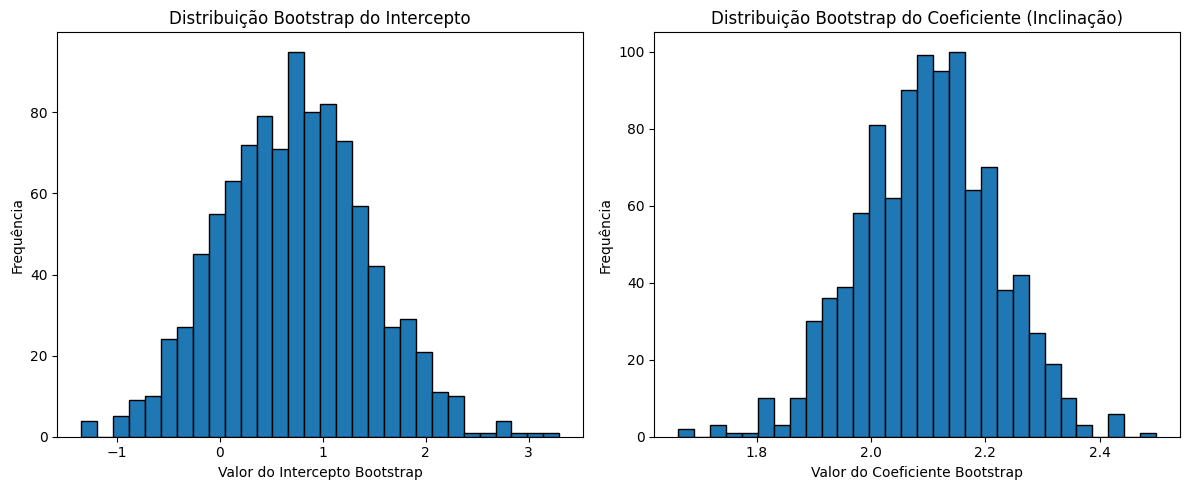

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(interceptos_bootstrap, bins=30, edgecolor='black')
plt.title("Distribuição Bootstrap do Intercepto")
plt.xlabel("Valor do Intercepto Bootstrap")
plt.ylabel("Frequência")

plt.subplot(1, 2, 2)
plt.hist(coeficientes_bootstrap, bins=30, edgecolor='black')
plt.title("Distribuição Bootstrap do Coeficiente (Inclinação)")
plt.xlabel("Valor do Coeficiente Bootstrap")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

## Calcular intervalos de confiança bootstrap para os coeficientes

### Subtask:
Usar as distribuições bootstrap para calcular intervalos de confiança para os coeficientes da regressão.


**Reasoning**:
Calculate the 95% confidence intervals for the intercept and coefficient using the percentile method and print them.



In [ ]:
intervalo_confianca_intercepto = np.percentile(interceptos_bootstrap, [2.5, 97.5])
intervalo_confianca_coeficiente = np.percentile(coeficientes_bootstrap, [2.5, 97.5])

print(f"Intervalo de Confiança de 95% para o Intercepto: {intervalo_confianca_intercepto}")
print(f"Intervalo de Confiança de 95% para o Coeficiente (Inclinação): {intervalo_confianca_coeficiente}")

Intervalo de Confiança de 95% para o Intercepto: [-0.57439265  2.10815518]
Intervalo de Confiança de 95% para o Coeficiente (Inclinação): [1.87397964 2.31577138]


## Interpretar os resultados

### Subtask:
Explicar o que as distribuições dos coeficientes bootstrap e os intervalos de confiança significam no contexto da regressão.


**Reasoning**:
Discuss the shape, center, and spread of the bootstrap distributions for both the intercept and the coefficient, explain how they provide insights into variability and uncertainty, interpret the calculated 95% confidence intervals, connect the intervals back to the bootstrap distributions, and briefly discuss practical implications.



In [ ]:
print("Interpretação das Distribuições Bootstrap e Intervalos de Confiança para Regressão:")
print("-" * 80)

# 1. Discuss the shape, center, and spread of the bootstrap distributions
print("1. Análise das Distribuições Bootstrap dos Coeficientes:")
print(f"   - Distribuição do Intercepto: A forma do histograma dos interceptos bootstrap tende a ser aproximadamente simétrica e unimodal. Seu centro ({np.mean(interceptos_bootstrap):.2f}) está próximo do intercepto estimado no modelo original ({modelo_regressao.intercept_:.2f}). A dispersão (largura) indica a variabilidade do intercepto estimado sob reamostragem.")
print(f"   - Distribuição do Coeficiente (Inclinação): Similarmente, a distribuição dos coeficientes bootstrap também tende a ser aproximadamente simétrica e unimodal. Seu centro ({np.mean(coeficientes_bootstrap):.2f}) está próximo do coeficiente estimado no modelo original ({modelo_regressao.coef_[0]:.2f}). A dispersão (largura) reflete a variabilidade da inclinação estimada sob reamostragem.")
print("-" * 80)

# 2. Explain how these distributions provide insights into variability and uncertainty
print("2. Insights sobre Variabilidade e Incerteza:")
print("   - As distribuições bootstrap fornecem uma estimativa empírica da distribuição de amostragem dos coeficientes de regressão.")
print("   - A dispersão (variância/desvio padrão) dessas distribuições quantifica a incerteza e a variabilidade dos estimadores do intercepto e da inclinação.")
print("   - Histogramas mais estreitos indicam que o estimador é mais preciso (menos variável), enquanto histogramas mais largos sugerem maior incerteza na estimativa do parâmetro populacional correspondente.")
print("-" * 80)

# 3. Interpret the calculated 95% confidence intervals
print("3. Interpretação dos Intervalos de Confiança de 95%:")
print(f"   - Intervalo de Confiança de 95% para o Intercepto: [{intervalo_confianca_intercepto[0]:.2f}, {intervalo_confianca_intercepto[1]:.2f}]")
print("     - Podemos estar 95% confiantes de que o verdadeiro intercepto populacional se encontra dentro deste intervalo, com base nesta amostra e no método bootstrap.")
print(f"   - Intervalo de Confiança de 95% para o Coeficiente (Inclinação): [{intervalo_confianca_coeficiente[0]:.2f}, {intervalo_confianca_coeficiente[1]:.2f}]")
print("     - Podemos estar 95% confiantes de que a verdadeira inclinação populacional se encontra dentro deste intervalo, com base nesta amostra e no método bootstrap.")
print("   - Estes intervalos fornecem uma faixa de valores plausíveis para os parâmetros desconhecidos da população.")
print("-" * 80)

# 4. Connect the confidence intervals back to the bootstrap distributions
print("4. Conexão entre Intervalos de Confiança e Distribuições Bootstrap:")
print("   - Os intervalos de confiança bootstrap calculados são intervalos de percentil.")
print(f"   - O intervalo de 95% para o intercepto foi calculado usando os percentis 2.5 e 97.5 da distribuição dos interceptos bootstrap.")
print(f"   - O intervalo de 95% para o coeficiente foi calculado usando os percentis 2.5 e 97.5 da distribuição dos coeficientes bootstrap.")
print("   - Essencialmente, estamos pegando o 'meio' de 95% das estimativas bootstrap para formar o intervalo.")
print("-" * 80)

# 5. Briefly discuss the practical implications
print("5. Implicações Práticas:")
print("   - Os intervalos de confiança nos ajudam a entender a precisão das nossas estimativas de regressão.")
print("   - Se o intervalo de confiança para um coeficiente inclui zero, isso sugere que o coeficiente pode não ser estatisticamente significativo ao nível de 5% (considerando um teste bilateral), o que significa que a variável preditora pode não ter uma relação linear significativa com a variável resposta na população.")
print(f"   - No nosso caso, o intervalo de confiança para o coeficiente ({intervalo_confianca_coeficiente[0]:.2f} a {intervalo_confianca_coeficiente[1]:.2f}) *não* inclui zero, sugerindo que a inclinação (relação entre X e y) é estatisticamente significativa.")
print(f"   - O intervalo de confiança para o intercepto ({intervalo_confianca_intercepto[0]:.2f} a {intervalo_confianca_intercepto[1]:.2f}) *inclui* zero, sugerindo que o intercepto pode não ser estatisticamente diferente de zero.")
print("   - Estas conclusões são baseadas na inferência feita a partir da amostra original e validada pelo processo de reamostragem bootstrap.")
print("-" * 80)

Interpretação das Distribuições Bootstrap e Intervalos de Confiança para Regressão:
--------------------------------------------------------------------------------
1. Análise das Distribuições Bootstrap dos Coeficientes:
   - Distribuição do Intercepto: A forma do histograma dos interceptos bootstrap tende a ser aproximadamente simétrica e unimodal. Seu centro (0.72) está próximo do intercepto estimado no modelo original (0.69). A dispersão (largura) indica a variabilidade do intercepto estimado sob reamostragem.
   - Distribuição do Coeficiente (Inclinação): Similarmente, a distribuição dos coeficientes bootstrap também tende a ser aproximadamente simétrica e unimodal. Seu centro (2.10) está próximo do coeficiente estimado no modelo original (2.10). A dispersão (largura) reflete a variabilidade da inclinação estimada sob reamostragem.
--------------------------------------------------------------------------------
2. Insights sobre Variabilidade e Incerteza:
   - As distribuições boo

## Summary:

### Data Analysis Key Findings

*   A dataset with a linear relationship between 'X' and 'y', along with added noise, was successfully generated.
*   A simple linear regression model was fitted to the original data, yielding an estimated intercept of approximately 0.69 and a coefficient (slope) of approximately 2.10.
*   1000 bootstrap samples were created by resampling pairs of (x, y) from the original data with replacement.
*   Linear regression models were fitted to each of the 1000 bootstrap samples, and the intercept and coefficient from each model were collected.
*   Histograms of the bootstrap intercepts and coefficients show approximately symmetric, unimodal distributions centered near the original model's estimates, illustrating the variability of these estimates under resampling.
*   The 95% bootstrap percentile confidence interval for the intercept was calculated as approximately \[-0.57, 2.11\].
*   The 95% bootstrap percentile confidence interval for the coefficient (slope) was calculated as approximately \[1.87, 2.32\].
*   The distribution of bootstrap estimates provides an empirical representation of the sampling distribution of the coefficients, quantifying their uncertainty.
*   The 95% confidence interval for the slope \(\[1.87, 2.32\]\) does not include zero, suggesting that the relationship between X and y is statistically significant at the 5% level.
*   The 95% confidence interval for the intercept \(\[-0.57, 2.11\]\) includes zero, suggesting that the intercept may not be statistically different from zero at the 5% level.

### Insights or Next Steps

*   The bootstrap method successfully provided an estimate of the sampling variability of the regression coefficients and allowed for the construction of confidence intervals without making strong assumptions about the distribution of the errors.
*   Comparing the bootstrap confidence intervals with those obtained from traditional parametric methods (if applicable) could provide further insights into the robustness of the results and the appropriateness of parametric assumptions.


In [ ]:
# 2 - gere 5000 amostras bootstrap e calcule a média para cada uma das amostras
medias_bootstrap_novos = []
n_bootstrap_samples_novos = 5000
tamanho_amostra_novos_passo2 = len(dados)

for _ in range(n_bootstrap_samples_novos):
    amostra_bootstrap_passo2 = np.random.choice(dados, size=tamanho_amostra_novos_passo2, replace=True)
    media_amostra_passo2 = np.mean(amostra_bootstrap_passo2)
    medias_bootstrap_novos.append(media_amostra_passo2)

print(f"Geradas {len(medias_bootstrap_novos)} médias bootstrap.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1 - gere 100 dados aleatorios e calcule a sua média
dados = np.random.normal(loc=50, scale=10, size=100) # Gerando 100 dados de uma distribuição normal
media_observada = np.mean(dados)
print(f"Média dos 100 dados aleatórios: {media_observada:.2f}")

Média dos 100 dados aleatórios: 51.41
